In [ ]:
# Cell 1 — Imports, Configuration & Data Loading

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Reproducibility
RANDOM_STATE = 42

# Load cleaned dataset

df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (100000, 19)


,customer_id,age,gender,city,acquisition_channel,subscription_plan,payment_method,signup_date,tenure_months,orders_count,monthly_spend,discount_usage_rate,support_tickets,satisfaction_score,last_order_date,churn,recency_days,orders_per_month,support_tickets_per_month
0,178303,23.0,Male,Ahmedabad,Referral,Standard,Wallet,2023-10-12,27,7,14545.09,0.666,1,5,2025-09-21,0,100,0.259259,0.037037
1,166465,48.0,Male,Mumbai,Social Media,Premium,Debit Card,2023-12-14,24,2,4134.45,0.173,3,4,2025-11-29,0,31,0.083333,0.125000
2,193228,31.0,Female,Delhi,Paid Ads,Basic,Debit Card,2024-02-25,22,1,776.62,0.499,0,5,2025-05-21,0,223,0.045455,0.000000
3,101748,46.0,Female,Pune,Social Media,Basic,Wallet,2024-07-18,17,1,1001.58,0.437,1,4,2025-12-23,1,7,0.058824,0.058824
4,180005,37.0,Female,Bangalore,Organic,Basic,Debit Card,2023-11-16,25,2,2383.86,0.629,5,2,2025-09-20,1,101,0.080000,0.200000


In [ ]:

# Cell 2 — Feature Selection & Train/Test Split


target = "churn"

features = [
    "age",
    "gender",
    "city",
    "acquisition_channel",
    "subscription_plan",
    "payment_method",
    "tenure_months",
    "orders_count",
    "monthly_spend",
    "discount_usage_rate",
    "support_tickets",
    "satisfaction_score",
    "recency_days",
    "orders_per_month",
    "support_tickets_per_month"
]

X = df[features]
y = df[target]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTrain churn distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (80000, 15)
Test set: (20000, 15)

Train churn distribution:
churn
0    0.728
1    0.272
Name: proportion, dtype: float64

Test churn distribution:
churn
0    0.728
1    0.272
Name: proportion, dtype: float64


In [ ]:

# Cell 3 — Preprocessing Pipeline


categorical_features = [
    "gender",
    "city",
    "acquisition_channel",
    "subscription_plan",
    "payment_method"
]

numerical_features = [
    "age",
    "tenure_months",
    "orders_count",
    "monthly_spend",
    "discount_usage_rate",
    "support_tickets",
    "satisfaction_score",
    "recency_days",
    "orders_per_month",
    "support_tickets_per_month"
]

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 10
Categorical features: 5


In [ ]:

# Cell 4 — Candidate Models


models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        verbose=False,
        random_seed=RANDOM_STATE
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=-1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
}

print("Candidate models:")
for name in models:
    print("-", name)

Candidate models:
- Logistic Regression
- Random Forest
- XGBoost
- CatBoost
- LightGBM


In [ ]:

# Cell 5 — Baseline Model Training & Comparison

results = []
trained_models = {}

for name, model in models.items():

    # Complete pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    trained_models[name] = pipeline


# Results table
results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CatBoost,0.8173,0.7249,0.5274,0.6106,0.8515
1,Logistic Regression,0.7690,0.5548,0.7559,0.6399,0.8500
2,LightGBM,0.8154,0.7176,0.5278,0.6083,0.8492
3,XGBoost,0.8161,0.7201,0.5282,0.6094,0.8492
4,Random Forest,0.8102,0.7283,0.4801,0.5787,0.8439


In [ ]:

# Cell 6 — Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV

# Pipelines

tuning_pipelines = {

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "CatBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostClassifier(
            verbose=False,
            random_seed=RANDOM_STATE,
            thread_count=-1
        ))
    ])
}


# Hyperparameter search spaces

param_distributions = {

    "Logistic Regression": {
        "model__C": np.logspace(-2, 1, 10),
        "model__solver": ["liblinear", "lbfgs"],
        "model__penalty": ["l2"]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300, 400],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5]
    },

    "CatBoost": {
        "model__iterations": [200, 300, 500],
        "model__depth": [4, 5, 6, 7, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__l2_leaf_reg": [1, 3, 5, 7, 10],
        "model__border_count": [32, 64, 128]
    }
}


# Randomized Search

tuned_models = {}
tuning_results = []

for name in tuning_pipelines:

    print(f"\nTuning {name}...")

    search = RandomizedSearchCV(
        estimator=tuning_pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=15,
        scoring="f1",
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    tuned_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best CV F1": search.best_score_,
        "Best Parameters": search.best_params_
    })

    print(f"Best CV F1: {search.best_score_:.4f}")
    print("Best Parameters:")
    print(search.best_params_)

# Tuning summary


tuning_results_df = pd.DataFrame(tuning_results)

display(tuning_results_df[["Model", "Best CV F1"]].style.format({
    "Best CV F1": "{:.4f}"
}))


Tuning Logistic Regression...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CV F1: 0.6440
Best Parameters:
{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': np.float64(0.021544346900318832)}

Tuning XGBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CV F1: 0.6062
Best Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}

Tuning CatBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CV F1: 0.6073
Best Parameters:
{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 10, 'model__iterations': 300, 'model__depth': 4, 'model__border_count': 32}


,Model,Best CV F1
0,Logistic Regression,0.6440
1,XGBoost,0.6062
2,CatBoost,0.6073


In [ ]:

# Cell 7 — Tuned Model Evaluation on Test Set


final_results = []
test_predictions = {}

for name, model in tuned_models.items():

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Store predictions for later analysis
    test_predictions[name] = {
        "pred": y_pred,
        "prob": y_prob
    }

    # Metrics
    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


final_results_df = pd.DataFrame(final_results)

# Sort by F1
final_results_df = (
    final_results_df
    .sort_values("F1-Score", ascending=False)
    .reset_index(drop=True)
)

display(
    final_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7691,0.5550,0.7557,0.6400,0.8500
1,XGBoost,0.8170,0.7231,0.5287,0.6108,0.8518
2,CatBoost,0.8165,0.7226,0.5265,0.6092,0.8516


Classification Report — Final Model

              precision    recall  f1-score   support

   Not Churn       0.89      0.77      0.83     14568
       Churn       0.55      0.76      0.64      5432

    accuracy                           0.77     20000
   macro avg       0.72      0.76      0.73     20000
weighted avg       0.80      0.77      0.78     20000



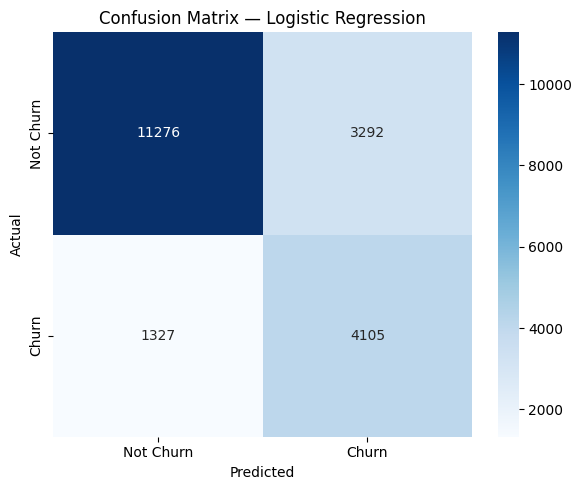

In [ ]:

# Cell 8 — Final Model Evaluation

from sklearn.metrics import classification_report, confusion_matrix

final_model = tuned_models["Logistic Regression"]

# Predictions
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report — Final Model\n")

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Not Churn", "Churn"]
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9 — Save Final Model

import joblib
import os

model_path = "../models/final_churn_model.pkl"

os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, model_path)

print("Final model saved to:")
print(model_path)

Final model saved to:
../models/final_churn_model.pkl
